#Análise da População dos municipios de Minas Gerais no ano de 2022.

##📚 Bibliotecas

Nesta etapa, importo as bibliotecas que serão utilizadas ao longo do projeto para realizar a coleta, manipulação, análise e visualização dos dados.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [ ]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##Coleta dos dados via API


Para obter os dados utilizados na análise, utilizei a API do IBGE. Primeiramente, realizei uma requisição à API e verifiquei o retorno da resposta para confirmar se os dados foram obtidos corretamente.

In [ ]:
url = "https://apisidra.ibge.gov.br/values/t/4709/n6/all/v/93/p/2022"

In [ ]:
resposta = requests.get(url)

In [ ]:
print(resposta.status_code)

200


##Transformação em DataFrame

Nesta etapa, os dados retornados pela API são convertidos para uma estrutura que possa ser manipulada pelo Pandas e, posteriormente, transformados em um DataFrame.

In [ ]:
dados = resposta.json()

In [ ]:
df = pd.DataFrame(dados)
df.head()

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Município (Código),Município,Variável (Código),Variável,Ano (Código),Ano
1,6,Município,45,Pessoas,21494,1100015,Alta Floresta D'Oeste - RO,93,População residente,2022,2022
2,6,Município,45,Pessoas,96833,1100023,Ariquemes - RO,93,População residente,2022,2022
3,6,Município,45,Pessoas,5351,1100031,Cabixi - RO,93,População residente,2022,2022
4,6,Município,45,Pessoas,86887,1100049,Cacoal - RO,93,População residente,2022,2022


##🔎 Análise exploratória inicial e Tratamento dos dados

Nesta etapa, inicio a Análise Exploratória dos Dados .O objetivo é compreender a estrutura do conjunto de dados antes de realizar qualquer tratamento ou análise mais aprofundada.

O conjunto de dados possui 5.571 linhas e 11 colunas.

In [ ]:
df.shape

(5571, 11)

A partir do info(), é possível verificar a quantidade de registros, as colunas existentes e os tipos de dados presentes inicialmente no DataFrame.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5571 entries, 0 to 5570
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NC      5571 non-null   object
 1   NN      5571 non-null   object
 2   MC      5571 non-null   object
 3   MN      5571 non-null   object
 4   V       5571 non-null   object
 5   D1C     5571 non-null   object
 6   D1N     5571 non-null   object
 7   D2C     5571 non-null   object
 8   D2N     5571 non-null   object
 9   D3C     5571 non-null   object
 10  D3N     5571 non-null   object
dtypes: object(11)
memory usage: 478.9+ KB


In [ ]:
print(df.columns)

Index(['NC', 'NN', 'MC', 'MN', 'V', 'D1C', 'D1N', 'D2C', 'D2N', 'D3C', 'D3N'], dtype='object')


Durante a coleta, a API retornou os nomes das colunas de uma forma que não era adequada para a análise. Por isso, realizei a renomeação das colunas para facilitar a interpretação e utilização dos dados ao longo do projeto.mudando o nome das colunas

In [ ]:
df = df.rename(columns={
    'NC': 'Nivel_Territorial_Cd',
    'NN': 'Nivel_Territorial',
    'MC': 'Unidade_Medida_Cd',
    'MN': 'Unidade_Medida',
    'V': 'Populacao',
    'D1C': 'Municipio_Cd',
    'D1N': 'Municipio',
    'D2C': 'Variavel_Cd',
    'D2N': 'Variavel',
    'D3C': 'Ano_Cd',
    'D3N': 'Ano'
})

Como os dados retornados pela API possuem uma estrutura específica, a informação que deveria representar os nomes das colunas acabou sendo interpretada como um registro do DataFrame. Por isso, foi necessário remover essa primeira linha antes de prosseguir com a análise.

In [ ]:
df = df.drop(0)
df

,Nivel_Territorial_Cd,Nivel_Territorial,Unidade_Medida_Cd,Unidade_Medida,Populacao,Municipio_Cd,Municipio,Variavel_Cd,Variavel,Ano_Cd,Ano
1,6,Município,45,Pessoas,21494,1100015,Alta Floresta D'Oeste - RO,93,População residente,2022,2022
2,6,Município,45,Pessoas,96833,1100023,Ariquemes - RO,93,População residente,2022,2022
3,6,Município,45,Pessoas,5351,1100031,Cabixi - RO,93,População residente,2022,2022
4,6,Município,45,Pessoas,86887,1100049,Cacoal - RO,93,População residente,2022,2022
5,6,Município,45,Pessoas,15890,1100056,Cerejeiras - RO,93,População residente,2022,2022
...,...,...,...,...,...,...,...,...,...,...,...
5566,6,Município,45,Pessoas,14956,5222005,Vianópolis - GO,93,População residente,2022,2022
5567,6,Município,45,Pessoas,8768,5222054,Vicentinópolis - GO,93,População residente,2022,2022
5568,6,Município,45,Pessoas,4215,5222203,Vila Boa - GO,93,População residente,2022,2022
5569,6,Município,45,Pessoas,5815,5222302,Vila Propício - GO,93,População residente,2022,2022


Verifico a existência de valores nulos para identificar possíveis informações ausentes que poderiam afetar as análises posteriores.

In [ ]:
df.isnull().sum()

,0
Nivel_Territorial_Cd,0
Nivel_Territorial,0
Unidade_Medida_Cd,0
Unidade_Medida,0
Populacao,0
Municipio_Cd,0
Municipio,0
Variavel_Cd,0
Variavel,0
Ano_Cd,0


Também verifico a existência de registros duplicados para garantir que uma mesma informação não seja contabilizada mais de uma vez.

In [ ]:
df.duplicated().sum()

np.int64(0)

Utilizo a estatística descritiva para obter uma visão inicial da distribuição dos dados numéricos, observando medidas como média, desvio padrão, valores mínimo e máximo.

In [ ]:
df.describe()

,Nivel_Territorial_Cd,Nivel_Territorial,Unidade_Medida_Cd,Unidade_Medida,Populacao,Municipio_Cd,Municipio,Variavel_Cd,Variavel,Ano_Cd,Ano
count,5570,5570,5570,5570,5570,5570,5570,5570,5570,5570,5570
unique,1,1,1,1,5069,5570,5570,1,1,1,1
top,6,Município,45,Pessoas,5228,5300108,Brasília - DF,93,População residente,2022,2022
freq,5570,5570,5570,5570,4,1,1,5570,5570,5570,5570


Removo algumas colunas

In [ ]:
df = df[
    [
        "Municipio_Cd",
        "Municipio",
        "Populacao",
        "Ano"
    ]
]

df

,Municipio_Cd,Municipio,Populacao,Ano
1,1100015,Alta Floresta D'Oeste - RO,21494,2022
2,1100023,Ariquemes - RO,96833,2022
3,1100031,Cabixi - RO,5351,2022
4,1100049,Cacoal - RO,86887,2022
5,1100056,Cerejeiras - RO,15890,2022
...,...,...,...,...
5566,5222005,Vianópolis - GO,14956,2022
5567,5222054,Vicentinópolis - GO,8768,2022
5568,5222203,Vila Boa - GO,4215,2022
5569,5222302,Vila Propício - GO,5815,2022


##Filtragem - Dados de Minas Gerais

Como o objetivo deste projeto é analisar a população dos municípios de Minas Gerais, realizo a filtragem do conjunto de dados para manter apenas os registros pertencentes ao estado.

In [ ]:
df_mg = df[df["Municipio"].str.contains("- MG")]
df_mg

,Municipio_Cd,Municipio,Populacao,Ano
2245,3100104,Abadia dos Dourados - MG,6272,2022
2246,3100203,Abaeté - MG,22675,2022
2247,3100302,Abre Campo - MG,13927,2022
2248,3100401,Acaiaca - MG,3909,2022
2249,3100500,Açucena - MG,8943,2022
...,...,...,...,...
3093,3171808,Virginópolis - MG,10314,2022
3094,3171907,Virgolândia - MG,4552,2022
3095,3172004,Visconde do Rio Branco - MG,39160,2022
3096,3172103,Volta Grande - MG,4443,2022


Após a filtragem, realizo a conversão dos tipos de dados para que cada variável possua o formato adequado à sua finalidade.

Algumas informações foram inicialmente interpretadas como object, por isso foi necessário convertê-las para seus respectivos tipos, como numérico ou categórico.

In [ ]:
df_mg['Ano'] = pd.to_datetime(df_mg['Ano'])
df_mg['Municipio_Cd'] = df_mg['Municipio_Cd'].astype(int)
df_mg['Populacao'] = df_mg['Populacao'].astype(int)
df_mg['Municipio'] = df_mg['Municipio'].astype(str)

/tmp/ipykernel_2087/1475822281.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mg['Ano'] = pd.to_datetime(df_mg['Ano'])
/tmp/ipykernel_2087/1475822281.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mg['Municipio_Cd'] = df_mg['Municipio_Cd'].astype(int)
/tmp/ipykernel_2087/1475822281.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

Verifico se está correto

In [ ]:
df_mg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 853 entries, 2245 to 3097
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Municipio_Cd  853 non-null    int64         
 1   Municipio     853 non-null    object        
 2   Populacao     853 non-null    int64         
 3   Ano           853 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 65.6+ KB


##📊 Análise dos dados

Nesta etapa, calculo a população total dos municípios analisados para compreender a dimensão populacional de Minas Gerais dentro do conjunto de dados.

In [ ]:
populacao_total = df_mg["Populacao"].sum()
print("População total de MG: ", populacao_total)

População total de MG:  20539989


Para identificar os municípios com maior população, ordeno os registros de forma decrescente e seleciono os 10 primeiros municípios.

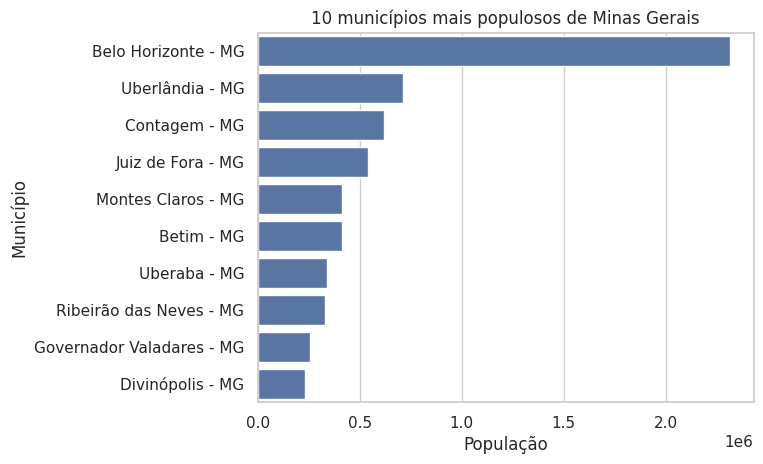

In [ ]:
top10 = df_mg.sort_values(
    "Populacao",
    ascending=False
).head(10)

sns.barplot(
    data=top10,
    x="Populacao",
    y="Municipio"
)

plt.title("10 municípios mais populosos de Minas Gerais")
plt.xlabel("População")
plt.ylabel("Município")
plt.show()

Calculo a média e a mediana da população dos municípios para compreender melhor a distribuição populacional.

A comparação entre essas duas medidas também permite observar se a distribuição apresenta influência de municípios com populações muito elevadas.

In [ ]:
media_populacao = df_mg['Populacao'].mean()
print("Média da População: ", round(media_populacao, 0))

Média da População:  24080.0


In [ ]:
mediana_populacao = df_mg["Populacao"].median()
print('A mediana da população é: ', mediana_populacao)

A mediana da população é:  8048.0


Identifico os municípios com maior e menor população e calculo a diferença entre esses valores para compreender a amplitude da distribuição populacional.

In [ ]:
maior = df_mg["Populacao"].max()
menor = df_mg["Populacao"].min()

diferenca = maior - menor

print(f"A diferença entre a maior população que é de: {maior} pessoas e a menor que é de {menor} pessoas é de {diferenca} pessoas" )

A diferença entre a maior população que é de: 2315560 pessoas e a menor que é de 833 pessoas é de 2314727 pessoas


Para facilitar a interpretação da distribuição populacional, criei uma nova variável chamada faixa_populacao.

Os municípios foram agrupados em diferentes faixas de população, permitindo analisar quantos municípios pertencem a cada categoria.

In [ ]:
df_mg["faixa_populacao"] = pd.cut(
    df_mg["Populacao"],
    bins=[0, 10000, 50000, 100000, 500000, float("inf")],
    labels=[
        "Até 10 mil",
        "10 mil a 50 mil",
        "50 mil a 100 mil",
        "100 mil a 500 mil",
        "Mais de 500 mil"
    ]
)



/tmp/ipykernel_2087/3664378857.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mg["faixa_populacao"] = pd.cut(


In [ ]:
df_mg["faixa_populacao"].value_counts()


,count
faixa_populacao,
Até 10 mil,482
10 mil a 50 mil,299
50 mil a 100 mil,38
100 mil a 500 mil,30
Mais de 500 mil,4


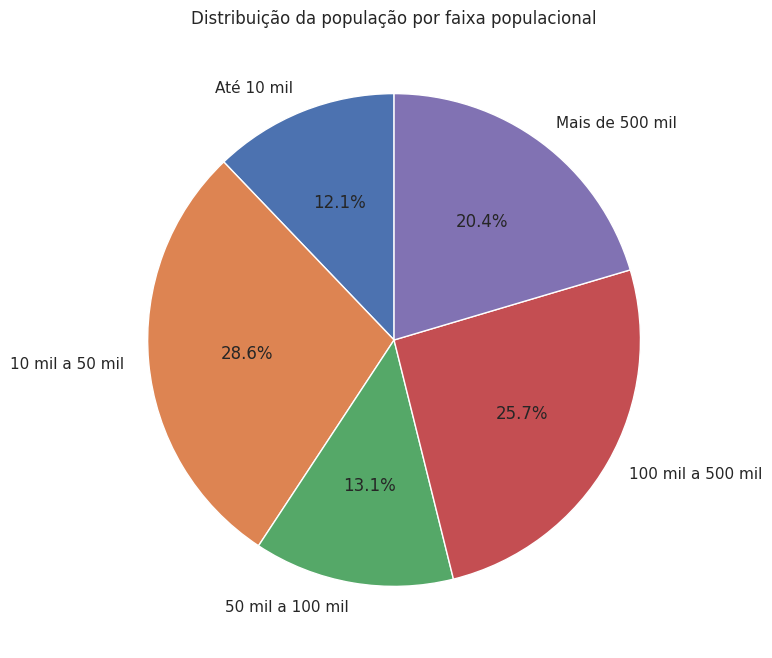

In [ ]:
populacao_faixa = df_mg.groupby(
    "faixa_populacao",
    observed=True
)["Populacao"].sum()

percentual = (
    populacao_faixa / populacao_faixa.sum() * 100
)

plt.figure(figsize=(8, 8))

plt.pie(
    percentual,
    labels=percentual.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribuição da população por faixa populacional")
plt.show()

#Relatório Final — Análise da População dos Municípios de Minas Gerais


## 1. Objetivo do projeto

O objetivo deste projeto foi realizar uma análise exploratória dos dados de população dos municípios de Minas Gerais, utilizando dados públicos disponibilizados pelo Instituto Brasileiro de Geografia e Estatística (IBGE).

A proposta foi desenvolver, na prática, um fluxo de análise de dados, desde a obtenção dos dados por meio de uma API até o tratamento, exploração e visualização das informações utilizando Python.

---

## 2. Extração dos dados

Os dados foram obtidos por meio da **API do IBGE/SIDRA**, permitindo estabelecer uma conexão entre a fonte pública de dados e o ambiente de análise.

A utilização da API possibilitou obter os dados diretamente do IBGE, evitando a necessidade de realizar o download manual de arquivos.

Após realizar a requisição utilizando a biblioteca `requests`, os dados foram convertidos para o formato adequado para análise com o Pandas.

---

## 3. Tratamento dos dados

Para o tratamento e organização dos dados foi utilizada a biblioteca **Pandas**.

Durante essa etapa foram realizadas análises para identificar:

* valores nulos;
* registros duplicados;
* tipos de dados das colunas;
* possíveis inconsistências;
* necessidade de conversão dos tipos de dados;
* seleção das informações relevantes para a análise.

Também foram realizadas alterações nos nomes das colunas para facilitar a compreensão e utilização dos dados.

As principais colunas utilizadas foram:

* `Municipio_Cd`: código de identificação do município;
* `Municipio`: nome do município;
* `Populacao`: população residente;
* `Ano`: ano de referência dos dados.

Uma etapa importante do tratamento foi a conversão da coluna de população para um formato numérico, permitindo realizar cálculos e análises estatísticas corretamente.

---

## 4. Análise Exploratória dos Dados — EDA

Após o tratamento, foi realizada uma **Análise Exploratória dos Dados (EDA)** com o objetivo de compreender melhor as características da população dos municípios analisados.

Foram utilizadas medidas estatísticas e operações de análise para identificar:

* população total;
* população média dos municípios;
* mediana;
* maior população;
* menor população;
* municípios mais populosos;
* municípios menos populosos;
* distribuição da população entre os municípios.

Essa etapa permitiu compreender a estrutura dos dados antes da criação das visualizações.

---

## 5. Visualização dos dados

Para a criação das visualizações foi utilizada principalmente a biblioteca **Seaborn**, em conjunto com o Matplotlib.

Os gráficos foram utilizados para facilitar a comparação entre os municípios e tornar os resultados da análise mais compreensíveis.

Entre as análises realizadas, foram consideradas comparações entre os municípios com maior e menor população, além da distribuição dos municípios de acordo com suas populações.

As visualizações permitem identificar diferenças significativas entre os municípios e compreender melhor como a população está distribuída.

---

## 6. Principais resultados

A análise permitiu observar que existe uma diferença significativa entre os municípios em relação ao número de habitantes.

Os municípios mais populosos concentram uma parcela relevante da população, enquanto uma grande quantidade de municípios apresenta populações significativamente menores.

A utilização de medidas como média, mediana, mínimo e máximo ajudou a compreender essa diferença, enquanto os gráficos facilitaram a comparação visual entre os municípios.

---

## 7. Tecnologias utilizadas

Durante o desenvolvimento do projeto foram utilizadas as seguintes tecnologias e bibliotecas:

* **Python** — linguagem utilizada para desenvolvimento da análise;
* **Requests** — utilizada para realizar a conexão com a API;
* **Pandas** — utilizada para tratamento, organização e análise dos dados;
* **Seaborn** — utilizada para criação das visualizações;
* **Matplotlib** — utilizada para complementar e personalizar os gráficos;
* **Google Colab** — ambiente utilizado para desenvolvimento do projeto;
* **API IBGE/SIDRA** — fonte dos dados públicos utilizados na análise.

---

## 8. Conclusão

O projeto possibilitou colocar em prática diferentes etapas de um processo de análise de dados, desde a extração das informações até a interpretação dos resultados.

A utilização da API do IBGE permitiu compreender como dados públicos podem ser obtidos de forma automatizada. Já o uso do Pandas possibilitou realizar o tratamento e a análise exploratória dos dados, enquanto Seaborn e Matplotlib contribuíram para transformar os resultados em visualizações mais fáceis de interpretar.

Além do desenvolvimento das habilidades técnicas em Python, o projeto contribuiu para compreender a importância de verificar a qualidade dos dados antes de realizar análises e para desenvolver um raciocínio mais estruturado na resolução de problemas utilizando dados.


## 👩‍💻 Sobre mim

Olá! Meu nome é **Lana Bartl** e sou estudante de **Arquitetura de Dados e Desenvolvimento de Sistemas**, com foco no desenvolvimento de conhecimentos em **Análise de Dados e Ciência de Dados**.

Sou uma pessoa curiosa, dedicada e gosto de entender como os dados podem ser utilizados para encontrar padrões, gerar informações e apoiar a tomada de decisões. Tenho estudado e desenvolvido projetos utilizando **Python, Pandas, SQL e Power BI**, buscando sempre transformar meus conhecimentos teóricos em aplicações práticas.

Neste projeto, coloquei em prática diferentes etapas de um processo de análise de dados, desde a **coleta das informações por meio de uma API até o tratamento, análise exploratória e visualização dos dados**.

Meu objetivo é continuar desenvolvendo minhas habilidades na área de dados, criando projetos que demonstrem minha evolução e, principalmente, meu interesse em aprender e resolver problemas utilizando dados.


#Projeto desenvolvido por: Lana Bartl Rodrigues - Gmail: lanarodriguesbr@gmail.com